# Célula 1 — Imports

In [47]:
from pathlib import Path
import random
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
 
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
 
import yfinance as yf
import requests
from arch import arch_model
from scipy.stats import spearmanr

In [48]:
def qlike(y_true, y_pred):
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)

def eval_metrics(y_true, y_pred, label):
    print(f"\n── {label} ──")
    print(f"  QLIKE    : {qlike(y_true, y_pred):.6f}  (baseline média: {qlike(y_true, np.full_like(y_true, y_true.mean())):.6f})")
    print(f"  R²       : {r2_score(y_true, y_pred):.4f}")
    print(f"  Spearman : {spearmanr(y_true, y_pred).statistic:.4f}")
    print(f"  std ratio: {y_pred.std() / y_true.std():.3f}  (ideal=1.0)")

# Célula 2 — Constantes 

In [49]:
START          = "2008-01-01"
END            = "2025-04-14"
TEST_RATIO     = 0.1
SEED           = 42
WINDOW_SIZE    = 60       
VOL_WINDOW     = 10    # era 21
VOL_SHIFT      = -5   # era -21
 
FRED_API_KEY   = "a75bdc9f7da239a5e3d6c8e389345bfb"
DATA_BASE_PATH = Path("./data")
 
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

# Célula 3 - Requição para API do FRED

In [50]:
def get_fred_series(series_id: str, start: str, end: str, api_key: str) -> pd.DataFrame:
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "observation_start": start,
        "observation_end": end,
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()["observations"]
    df = pd.DataFrame(data)[["date", "value"]]
    df.columns = ["timestamp", series_id.lower()]
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df[series_id.lower()] = pd.to_numeric(df[series_id.lower()], errors="coerce")
    return df.reset_index(drop=True)
 
dfii10 = get_fred_series("DFII10", START, END, FRED_API_KEY)
dfii10 = dfii10.rename(columns={"dfii10": "inflation"})
print(dfii10.shape)
print(dfii10.head())

(4510, 2)
   timestamp  inflation
0 2008-01-01        NaN
1 2008-01-02       1.59
2 2008-01-03       1.58
3 2008-01-04       1.56
4 2008-01-07       1.57


# Células 4, 5, 6 e 7 - Carrega dataframes

In [51]:
petrodolar = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_5_daily_prices_fx.csv",
    parse_dates=["date"]
)
petrodolar = petrodolar.rename(columns={"date": "timestamp"})
petrodolar = petrodolar[[
    "timestamp",
    "brent_crude_usd",
    "wti_crude_usd",
    "brent_wti_spread",
    "usd_dxy_index",
    "eur_usd",
    "usd_rub",
]]
petrodolar = petrodolar[
    (petrodolar["timestamp"] >= START) &
    (petrodolar["timestamp"] <= END)
].reset_index(drop=True)

print(petrodolar.shape)
print(petrodolar.head())

(4510, 7)
   timestamp  brent_crude_usd  wti_crude_usd  brent_wti_spread  usd_dxy_index  \
0 2008-01-01            95.43          89.45              5.98          81.79   
1 2008-01-02            95.20          90.40              4.80          80.31   
2 2008-01-03            93.60          90.02              3.58          81.91   
3 2008-01-04            94.70          92.72              1.98          81.00   
4 2008-01-07            94.69          89.33              5.36          80.54   

   eur_usd  usd_rub  
0   1.2725    30.51  
1   1.2891    30.16  
2   1.2693    29.76  
3   1.2834    29.98  
4   1.2971    30.36  


In [52]:
opec = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_2_opec_quotas_events.csv",
    parse_dates=["date"]
)
opec = opec.rename(columns={"date": "timestamp"})
opec["timestamp"] = pd.to_datetime(opec["timestamp"])
opec = opec[[
    "timestamp",
    "opec_compliance_pct",
    "oil_market_balance_mbd",
    "us_shale_production_mbd",
]].copy()

# Dataset 4 — Dedolarização
dedolar = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_4_dedollarization.csv",
    parse_dates=["date"]
)
dedolar = dedolar.rename(columns={"date": "timestamp"})
dedolar["timestamp"] = pd.to_datetime(dedolar["timestamp"])
dedolar = dedolar[[
    "timestamp",
    "de_dollarization_pressure_index",
    "brics_gold_reserves_tonnes",
    "usd_global_fx_reserves_pct",
]].copy()

# Dataset 3 — SWF (anual)
swf = pd.read_csv(DATA_BASE_PATH / "petrodollar_3_recycling_swf.csv")
swf = swf[["year", "global_fx_reserves_gold_share_pct"]].copy()

print("OPEC:", opec.shape)
print("Dedolar:", dedolar.shape)
print("SWF:", swf.shape)

OPEC: (312, 4)
Dedolar: (252, 4)
SWF: (26, 2)


In [53]:
tickers = {
    "dxy":   "DX-Y.NYB",
    "vix":   "^VIX",
    "oil":   "CL=F",
    "tips":  "TIP",
    "sp500": "^GSPC",
    "tnx": "^TNX",
    "gvz":   "^GVZ",
}

dfs = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    close = df["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.name = name
    dfs[name] = close

externos = pd.concat(dfs.values(), axis=1)
externos.index.name = "timestamp"
externos = externos.reset_index()

print(externos.shape)
print(externos.head())

(4350, 8)
   timestamp        dxy        vix        oil       tips        sp500    tnx  \
0 2008-01-02  75.970001  23.170000  99.620003  62.980545  1447.160034  3.901   
1 2008-01-03  75.889999  22.490000  99.180000  63.193089  1447.160034  3.901   
2 2008-01-04  75.790001  23.940001  97.910004  63.175396  1411.630005  3.854   
3 2008-01-07  76.169998  23.790001  95.089996  63.163544  1416.180054  3.839   
4 2008-01-08  76.110001  25.430000  96.330002  63.210861  1390.189941  3.840   

   gvz  
0  NaN  
1  NaN  
2  NaN  
3  NaN  
4  NaN  


C:\Users\fpaul\AppData\Local\Temp\ipykernel_21340\1846522701.py:20: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  externos = pd.concat(dfs.values(), axis=1)


In [54]:
gold      = pd.read_csv(DATA_BASE_PATH / "final_gold_data.csv",      sep=";", encoding="utf-8", parse_dates=["timestamp"])
palladium = pd.read_csv(DATA_BASE_PATH / "final_palladium_data.csv", sep=";", encoding="utf-8", parse_dates=["timestamp"])
platinum  = pd.read_csv(DATA_BASE_PATH / "final_platinum_data.csv",  sep=";", encoding="utf-8", parse_dates=["timestamp"])
silver    = pd.read_csv(DATA_BASE_PATH / "final_silver_data.csv",    sep=";", encoding="utf-8", parse_dates=["timestamp"])

cols_to_drop = ["currency", "unit", "headlines"]
for name, df in [("palladium", palladium), ("platinum", platinum), ("silver", silver)]:
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    df.rename(columns={
        "open":   f"{name}_open",
        "high":   f"{name}_high",
        "low":    f"{name}_low",
        "close":  f"{name}_close",
        "volume": f"{name}_volume",
    }, inplace=True)

print("Gold:", gold.shape)

Gold: (6177, 9)


# Célula 8 - Merges

In [55]:
for df in [gold, palladium, platinum, silver, externos]:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

gold = gold.merge(palladium,  on="timestamp", how="left")
gold = gold.merge(platinum,   on="timestamp", how="left")
gold = gold.merge(silver,     on="timestamp", how="left")
gold = gold.merge(externos,   on="timestamp", how="left")
gold = gold.merge(dfii10,     on="timestamp", how="left")
gold = gold.merge(petrodolar, on="timestamp", how="left")

# Merge mensal: OPEC e dedolarização (merge por ano+mês)
gold["year"]  = gold["timestamp"].dt.year
gold["month_"] = gold["timestamp"].dt.month

opec["year"]   = opec["timestamp"].dt.year
opec["month_"] = opec["timestamp"].dt.month
opec = opec.drop(columns=["timestamp"])

dedolar["year"]   = dedolar["timestamp"].dt.year
dedolar["month_"] = dedolar["timestamp"].dt.month
dedolar = dedolar.drop(columns=["timestamp"])

gold = gold.merge(opec,    on=["year", "month_"], how="left")
gold = gold.merge(dedolar, on=["year", "month_"], how="left")
gold = gold.merge(swf,     on="year",             how="left")
gold = gold.drop(columns=["year", "month_"])

fill_cols = [
    "dxy", "vix", "oil", "tips", "sp500", "tnx",
    "palladium_close", "palladium_open", "palladium_high", "palladium_low",
    "platinum_close",  "platinum_open",  "platinum_high",  "platinum_low",
    "silver_close",    "silver_open",    "silver_high",    "silver_low",
    "inflation",
    "brent_crude_usd", "wti_crude_usd", "brent_wti_spread", "usd_dxy_index", "eur_usd", "usd_rub",
    "opec_compliance_pct", "oil_market_balance_mbd", "us_shale_production_mbd",
    "de_dollarization_pressure_index", "brics_gold_reserves_tonnes", "usd_global_fx_reserves_pct",
    "global_fx_reserves_gold_share_pct",
]

gold[fill_cols] = gold[fill_cols].ffill().bfill()
gold = gold.dropna()

print("Shape após merge:", gold.shape)
print(gold.isna().sum()[gold.isna().sum() > 0])

Shape após merge: (3939, 45)
Series([], dtype: int64)


# Célula 9 - Feature Engineering

In [56]:
gold["day_variation"]  = gold["open"] - gold["close"]
gold["tomorrow_close"] = gold["close"].shift(-1)
gold = gold.dropna(subset=["tomorrow_close"])
 
gold["target_return"] = (gold["tomorrow_close"] - gold["close"]) / gold["close"]
gold["month"]         = gold["timestamp"].dt.month
 
gold["sma_5"]     = gold["close"].rolling(5).mean()
gold["sma_20"]    = gold["close"].rolling(20).mean()
gold["sma_ratio"] = gold["sma_5"] / gold["sma_20"]   # <- adimensional, mantida
 
ema_12 = gold["close"].ewm(span=12).mean()
ema_26 = gold["close"].ewm(span=26).mean()
gold["macd"]        = ema_12 - ema_26
gold["macd_signal"] = gold["macd"].ewm(span=9).mean()
 
rolling_std         = gold["close"].rolling(20).std()
gold["bb_position"] = (gold["close"] - (gold["sma_20"] - 2*rolling_std)) / (4 * rolling_std)  # adimensional [0,1]
 
gold["roc_10"] = gold["close"].pct_change(10)
 
gold["real_rate_proxy"] = gold["tnx"] - gold["inflation"]
gold["petrodolar_brent"] = gold["brent_crude_usd"] / gold["usd_dxy_index"]
gold["brent_roc_20"]     = gold["brent_crude_usd"].pct_change(20)
gold["brent_vol_20"]     = gold["brent_crude_usd"].pct_change().rolling(20).std()
gold["close_return"] = gold["close"].pct_change()
gold["gvz_pct_change"] = gold["gvz"].pct_change(5)
gold["gvz_zscore_60d"] = (
    (gold["gvz"] - gold["gvz"].rolling(60).mean())
    / gold["gvz"].rolling(60).std()
)
 
delta    = gold["close"].diff()
gain     = delta.clip(lower=0)
loss     = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs       = avg_gain / avg_loss
gold["rsi_14"] = 100 - (100 / (1 + rs))
 
gold["log_return"] = np.log(gold["close"] / gold["close"].shift(1))
gold["hist_vol_5"]  = gold["log_return"].rolling(5).std()
gold["hist_vol_10"] = gold["log_return"].rolling(10).std()
gold["hist_vol_20"] = gold["log_return"].rolling(20).std()
gold["hist_vol_60"] = gold["log_return"].rolling(60).std()

gold["target_vol_5d"] = gold["log_return"].rolling(VOL_WINDOW).std().shift(VOL_SHIFT)

gold = gold.dropna()
print("Shape após feature engineering:", gold.shape)
print("NaN restantes:", gold.isna().sum().sum())


Shape após feature engineering: (3873, 70)
NaN restantes: 0


In [57]:
# Fit GARCH no treino completo e extrair volatilidade condicional
log_ret = gold["log_return"].dropna() * 100
garch_full = arch_model(log_ret, vol="Garch", p=1, q=1)
res_full = garch_full.fit(disp="off")

gold_aligned = gold[gold["log_return"].notna()].copy()
gold_aligned["garch_vol"] = res_full.conditional_volatility.values / 100

gold = gold.merge(
    gold_aligned[["timestamp", "garch_vol"]],
    on="timestamp", how="left"
)

# Célula 10 - Target

In [58]:
TARGET = "target_vol_5d"
 
to_drop = [
    "currency", "unit", "timestamp", "headlines",
    "tomorrow_close", "target_return", "log_return",
    "close"
]
 
# MELHORIA 2: removidas features em nível absoluto de preço
cols_to_remove = [
    # Nível absoluto de preço -> leakage indireto via autocorrelação do close
    "sma_5",         # substituída por sma_ratio
    "sma_20",        # substituída por sma_ratio
    "bb_upper",      # substituída por bb_position
    "bb_lower",      # substituída por bb_position
    "high", "low", "open",   # em nível — usar só close como âncora temporal
 
    # Redundâncias conhecidas
    "wti_crude_usd",
    "petrodolar_wti",
    "usd_dxy_index",   # duplicata do dxy
    "max_diff",
    "silver_low",
    "platinum_volume",
    "palladium_volume",
    "gvz",
    "gvz_vix_spread",
    "garch_vol",   # fitado em todo o dataset — leakage
    "gvz",
    "gvz_vix_spread",
]
 
X = gold.drop(columns=[c for c in to_drop + [TARGET] + cols_to_remove if c in gold.columns])
y = gold[TARGET]
 
n_features = X.shape[1]
print("Features restantes:", list(X.columns))
print("n_features:", n_features)

Features restantes: ['volume', 'palladium_open', 'palladium_high', 'palladium_low', 'palladium_close', 'platinum_open', 'platinum_high', 'platinum_low', 'platinum_close', 'silver_open', 'silver_high', 'silver_close', 'silver_volume', 'dxy', 'vix', 'oil', 'tips', 'sp500', 'tnx', 'inflation', 'brent_crude_usd', 'brent_wti_spread', 'eur_usd', 'usd_rub', 'opec_compliance_pct', 'oil_market_balance_mbd', 'us_shale_production_mbd', 'de_dollarization_pressure_index', 'brics_gold_reserves_tonnes', 'usd_global_fx_reserves_pct', 'global_fx_reserves_gold_share_pct', 'day_variation', 'month', 'sma_ratio', 'macd', 'macd_signal', 'bb_position', 'roc_10', 'real_rate_proxy', 'petrodolar_brent', 'brent_roc_20', 'brent_vol_20', 'close_return', 'gvz_pct_change', 'gvz_zscore_60d', 'rsi_14', 'hist_vol_5', 'hist_vol_10', 'hist_vol_20', 'hist_vol_60']
n_features: 50


In [59]:
split_idx = int(len(gold) * (1 - TEST_RATIO))
 
vix_train = gold["vix"].iloc[:split_idx].values
vix_test  = gold["vix"].iloc[split_idx:].values
y_train_bl = y.iloc[:split_idx].values
y_test_bl  = y.iloc[split_idx:].values
 
# Regressão linear simples VIX → target_vol
ridge_bl = Ridge(alpha=1.0)
ridge_bl.fit(vix_train.reshape(-1, 1), y_train_bl)
vix_pred_test = ridge_bl.predict(vix_test.reshape(-1, 1))
 
r2_vix  = r2_score(y_test_bl, vix_pred_test)
mae_vix = mean_absolute_error(y_test_bl, vix_pred_test)
print(f"\n── Baseline VIX -> vol ──")
print(f"  R²  (teste): {r2_vix:.4f}")
print(f"  MAE (teste): {mae_vix:.6f}")
print(f"  Correlação : {np.corrcoef(y_test_bl, vix_pred_test)[0,1]:.4f}")
print("  (O LSTM precisa superar esse baseline para justificar sua complexidade)")



── Baseline VIX -> vol ──
  R²  (teste): -0.2424
  MAE (teste): 0.002305
  Correlação : -0.0628
  (O LSTM precisa superar esse baseline para justificar sua complexidade)


# Célula 11 - Create sequences

In [60]:
# Célula 7 — Sequences + split
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i + window_size])
        ys.append(y.iloc[i + window_size])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X.to_numpy(), y, WINDOW_SIZE)

mask  = ~np.isnan(y_seq)
X_seq = X_seq[mask]
y_seq = y_seq[mask]

print("NaN em y_seq após mask:", np.isnan(y_seq).sum())

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_seq, y_seq, test_size=TEST_RATIO, shuffle=False
)

print("Train:", X_train_full.shape, "Test:", X_test.shape)

NaN em y_seq após mask: 0
Train: (3431, 60, 50) Test: (382, 60, 50)


# Célula 12 - Criação do modelo

In [61]:
from tensorflow.keras.layers import GRU

def build_model(learning_rate=0.0001):
    model = Sequential([
        Input(shape=(WINDOW_SIZE, n_features)),
        GRU(64),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate), loss="huber")
    return model

# Célula 13 - Normalização

In [62]:
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(
    X_train_full.reshape(-1, n_features)
).reshape(X_train_full.shape)
X_test_scaled = x_scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_full.reshape(-1, 1)).ravel()

print("X_train_scaled:", X_train_scaled.shape)
print("y_train_scaled mean:", y_train_scaled.mean(), "std:", y_train_scaled.std())

X_train_scaled: (3431, 60, 50)
y_train_scaled mean: -1.1597316584834046e-16 std: 1.0


# Célula 14 - Separação em treino e teste

In [63]:
tscv = TimeSeriesSplit(n_splits=5)
folds = list(tscv.split(X_seq))

walk_r2s = []
last_val_idx = None  # <- salva índices, não os dados escalados

for fold, (train_idx, val_idx) in enumerate(folds):
    X_tr = X_seq[train_idx];  X_va = X_seq[val_idx]
    y_tr = y_seq[train_idx];  y_va = y_seq[val_idx]

    sc_x = StandardScaler()
    X_tr_s = sc_x.fit_transform(X_tr.reshape(-1, n_features)).reshape(X_tr.shape)
    X_va_s = sc_x.transform(X_va.reshape(-1, n_features)).reshape(X_va.shape)

    sc_y = StandardScaler()
    y_tr_s = sc_y.fit_transform(y_tr.reshape(-1, 1)).ravel()
    y_va_s = sc_y.transform(y_va.reshape(-1, 1)).ravel()

    tf.keras.backend.clear_session()
    m = build_model()
    m.fit(
        X_tr_s, y_tr_s,
        epochs=100, batch_size=32,
        validation_data=(X_va_s, y_va_s),
        shuffle=False, verbose=0,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True, min_delta=1e-5)]
    )

    pred_s = m.predict(X_va_s, verbose=0)
    pred   = sc_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()
    r2 = r2_score(y_va, pred)
    walk_r2s.append(r2)
    print(f"Fold {fold+1} R²: {r2:.4f}  |  pred_std: {pred.std():.6f}  |  real_std: {y_va.std():.6f}")

    if fold == len(folds) - 1:
        last_val_idx = val_idx  # <- só os índices

print(f"\nR² médio walk-forward: {np.mean(walk_r2s):.4f}")

# Reescalar com o scaler global 
val_X_final = x_scaler.transform(
    X_seq[last_val_idx].reshape(-1, n_features)
).reshape(X_seq[last_val_idx].shape)

val_y_final = y_scaler.transform(
    y_seq[last_val_idx].reshape(-1, 1)
).ravel()

Fold 1 R²: -0.4101  |  pred_std: 0.004413  |  real_std: 0.004961
Fold 2 R²: 0.0501  |  pred_std: 0.001338  |  real_std: 0.002873
Fold 3 R²: -0.1417  |  pred_std: 0.001060  |  real_std: 0.003272
Fold 4 R²: 0.0568  |  pred_std: 0.002584  |  real_std: 0.004440
Fold 5 R²: -0.0397  |  pred_std: 0.001753  |  real_std: 0.002768

R² médio walk-forward: -0.0969


# Célula 15 - Treino

In [64]:
TRAIN_YEARS = 4

seq_ts = gold["timestamp"].iloc[WINDOW_SIZE:].reset_index(drop=True)
seq_ts = seq_ts.iloc[mask].reset_index(drop=True)

test_start  = seq_ts.iloc[int(len(seq_ts) * (1 - TEST_RATIO))]
train_end   = test_start
train_start = train_end - pd.DateOffset(years=TRAIN_YEARS)

slide_mask = (seq_ts >= train_start) & (seq_ts < train_end)
slide_mask = slide_mask.values

X_slide = X_seq[slide_mask]
y_slide = y_seq[slide_mask]

print(f"Janela de treino: {train_start.date()} → {train_end.date()}")
print(f"Amostras: {X_slide.shape}")

x_scaler_slide = StandardScaler()
X_slide_s = x_scaler_slide.fit_transform(
    X_slide.reshape(-1, n_features)
).reshape(X_slide.shape)

y_scaler_slide = StandardScaler()
y_slide_s = y_scaler_slide.fit_transform(y_slide.reshape(-1, 1)).ravel()

# Escala o teste com o scaler da janela deslizante
X_test_slide_s = x_scaler_slide.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

# Val set = últimos 15% da janela deslizante (dentro do treino)
val_cut = int(len(X_slide_s) * 0.85)
val_X_slide  = X_slide_s[val_cut:]
val_y_slide  = y_slide_s[val_cut:]
X_slide_train = X_slide_s[:val_cut]
y_slide_train = y_slide_s[:val_cut]

print(f"Treino: {X_slide_train.shape}  Val: {val_X_slide.shape}")

tf.keras.backend.clear_session()
final_model = build_model()

history = final_model.fit(
    X_slide_train, y_slide_train,
    validation_data=(val_X_slide, val_y_slide),
    epochs=500,
    batch_size=32,
    shuffle=False,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=20,
                      restore_best_weights=True, min_delta=1e-6),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=15, min_lr=1e-6, verbose=1),
    ],
    verbose=1,
)

y_pred_slide_train = y_scaler_slide.inverse_transform(
    final_model.predict(X_slide_train, verbose=0)
).flatten()

y_pred_slide_test = y_scaler_slide.inverse_transform(
    final_model.predict(X_test_slide_s, verbose=0)
).flatten()

y_test_eval = y_test

eval_metrics(y_slide[:val_cut], y_pred_slide_train, "LSTM TRAIN (slide)")
eval_metrics(y_test_eval,       y_pred_slide_test,  "LSTM TEST  (slide)")

Janela de treino: 2019-09-26 → 2023-09-26
Amostras: (1006, 60, 50)
Treino: (855, 60, 50)  Val: (151, 60, 50)
Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.4640 - val_loss: 0.1924 - learning_rate: 1.0000e-04
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3987 - val_loss: 0.1918 - learning_rate: 1.0000e-04
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3599 - val_loss: 0.1918 - learning_rate: 1.0000e-04
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3316 - val_loss: 0.1915 - learning_rate: 1.0000e-04
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.3095 - val_loss: 0.1902 - learning_rate: 1.0000e-04
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.2916 - val_loss: 0.1884 - learning_rate: 1.0000e-04
Epoch 7/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.2764 - val_loss: 0.1860 - learning_rate: 1.0000e-04
Epoch 8/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.2632 - val_loss: 0.1834 - learn

In [65]:
print("y_train_scaled mean:", y_train_scaled.mean())
print("y_train_scaled std: ", y_train_scaled.std())
print("y_train_scaled min: ", y_train_scaled.min())
print("y_train_scaled max: ", y_train_scaled.max())
print("NaN em y_train_scaled:", np.isnan(y_train_scaled).sum())
print("NaN em X_train_scaled:", np.isnan(X_train_scaled).sum())

y_train_scaled mean: -1.1597316584834046e-16
y_train_scaled std:  1.0
y_train_scaled min:  -1.673489327255498
y_train_scaled max:  6.613354941262804
NaN em y_train_scaled: 0
NaN em X_train_scaled: 0


In [66]:
nan_cols = X.columns[X.isna().any()].tolist()
print("Colunas com NaN:", nan_cols)
print(X[nan_cols].isna().sum())

Colunas com NaN: []
Series([], dtype: float64)


# Célula 16 - Métricas

In [67]:
y_pred_train = y_scaler.inverse_transform(
    final_model.predict(X_train_scaled)
).flatten()
y_pred_test = y_scaler.inverse_transform(
    final_model.predict(X_test_scaled)
).flatten()
 
print("Pred treino std:", y_pred_train.std())
print("Real treino std:", y_train_full.std())
print("Pred teste  std:", y_pred_test.std())
print("Real teste  std:", y_test.std())
 
for name, y_true, y_pred in [
    ("TRAIN", y_train_full, y_pred_train),
    ("TEST",  y_test,       y_pred_test),
]:
    print(f"\n{'='*60}\n{name} METRICS\n{'='*60}")
    print("MAE:  ", mean_absolute_error(y_true, y_pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:   ", r2_score(y_true, y_pred))
    baseline = np.full_like(y_true, fill_value=y_train_full.mean())
    print("R2 baseline (média):", r2_score(y_true, baseline))
    print("R2 baseline (VIX)  :", r2_vix, "<- barra real a superar")
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    print("Correlação pred vs real:", corr)

108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Pred treino std: 0.0024331936
Real treino std: 0.0042499883543624505
Pred teste  std: 0.001220365
Real teste  std: 0.0025832569532560643

TRAIN METRICS
MAE:   0.002462200377471126
RMSE:  0.0034789621777500963
R2:    0.3299241985586665
R2 baseline (média): 0.0
R2 baseline (VIX)  : -0.24240331302153284 <- barra real a superar
Correlação pred vs real: 0.5762501364366799

TEST METRICS
MAE:   0.0022954113683073714
RMSE:  0.002693188377345031
R2:    -0.08692167420164143
R2 baseline (média): -0.009212391453195856
R2 baseline (VIX)  : -0.24240331302153284 <- barra real a superar
Correlação pred vs real: 0.3743375757637504


In [68]:
y_pred_train = y_scaler.inverse_transform(
    final_model.predict(X_train_scaled)
).flatten()
y_pred_test = y_scaler.inverse_transform(
    final_model.predict(X_test_scaled)
).flatten()

eval_metrics(y_train_full, y_pred_train, "LSTM TRAIN")
eval_metrics(y_test,       y_pred_test,  "LSTM TEST")

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

── LSTM TRAIN ──
  QLIKE    : 0.060150  (baseline média: 0.086905)
  R²       : 0.3299
  Spearman : 0.4997
  std ratio: 0.573  (ideal=1.0)

── LSTM TEST ──
  QLIKE    : 0.042867  (baseline média: 0.041665)
  R²       : -0.0869
  Spearman : 0.3848
  std ratio: 0.472  (ideal=1.0)


In [69]:
seq_ts = gold["timestamp"].iloc[WINDOW_SIZE:].reset_index(drop=True)
seq_ts = seq_ts.iloc[mask]

test_start = seq_ts.iloc[int(len(seq_ts) * (1 - TEST_RATIO))]
test_end   = seq_ts.iloc[-1]

print(f"Teste: {test_start.date()} → {test_end.date()}")
print(f"Dias no teste: {len(y_test)}")
print(f"Dias no treino completo: {len(y_train_full)}")

Teste: 2023-09-26 → 2025-04-03
Dias no teste: 382
Dias no treino completo: 3431


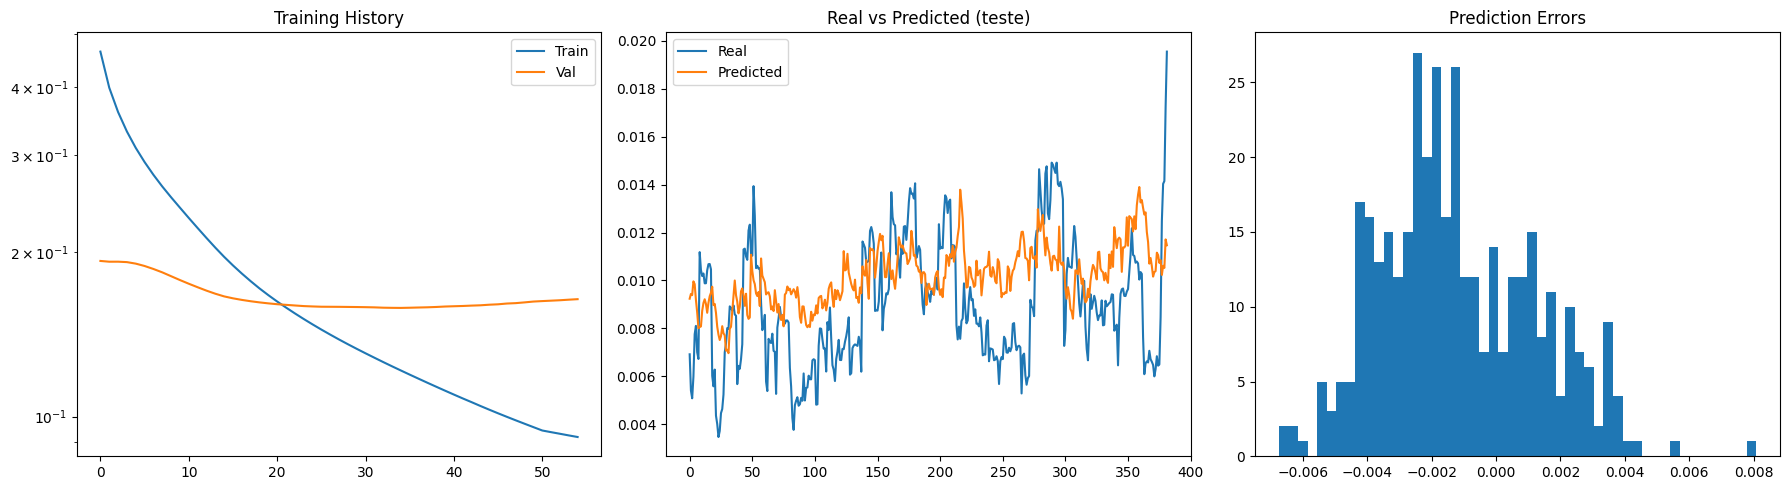


── Correlações com o target (novo) ──
hist_vol_5                 0.768824
hist_vol_10                0.675678
hist_vol_20                0.621365
hist_vol_60                0.539015
vix                        0.443846
oil_market_balance_mbd     0.310832
gvz_zscore_60d             0.291202
eur_usd                    0.266548
gvz_pct_change             0.238497
usd_rub                   -0.232861
dxy                       -0.208508
us_shale_production_mbd   -0.191567
platinum_high              0.187084
platinum_open              0.186330
platinum_close             0.186042
Name: target, dtype: float64


In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].plot(history.history["loss"],     label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_yscale("log")
axes[0].set_title("Training History")
axes[0].legend()
 
axes[1].plot(y_test,                label="Real")
axes[1].plot(y_pred_test.flatten(), label="Predicted")
axes[1].set_title("Real vs Predicted (teste)")
axes[1].legend()
 
errors = y_test - y_pred_test.flatten()
axes[2].hist(errors, bins=50)
axes[2].set_title("Prediction Errors")
 
plt.tight_layout()
plt.show()
 
print("\n── Correlações com o target (novo) ──")
corr_df = pd.DataFrame(X.values, columns=X.columns)
corr_df["target"] = y.values[:len(corr_df)]
correlations = corr_df.corr()["target"].drop("target").sort_values(key=abs, ascending=False)
print(correlations.head(15))


In [71]:
eval_metrics(y_slide[:val_cut], y_pred_slide_train, "LSTM TRAIN (slide)")
eval_metrics(y_test,            y_pred_slide_test,  "LSTM TEST  (slide)")


── LSTM TRAIN (slide) ──
  QLIKE    : 0.024575  (baseline média: 0.085982)
  R²       : 0.7519
  Spearman : 0.7870
  std ratio: 0.766  (ideal=1.0)

── LSTM TEST  (slide) ──
  QLIKE    : 0.041871  (baseline média: 0.041665)
  R²       : 0.0752
  Spearman : 0.4291
  std ratio: 0.559  (ideal=1.0)


In [72]:
print(pd.Series(y).autocorr(1))
print(pd.Series(y).autocorr(5))
print(pd.Series(y).autocorr(20))

0.9353509903681427
0.6754590911900957
0.3456808462267881


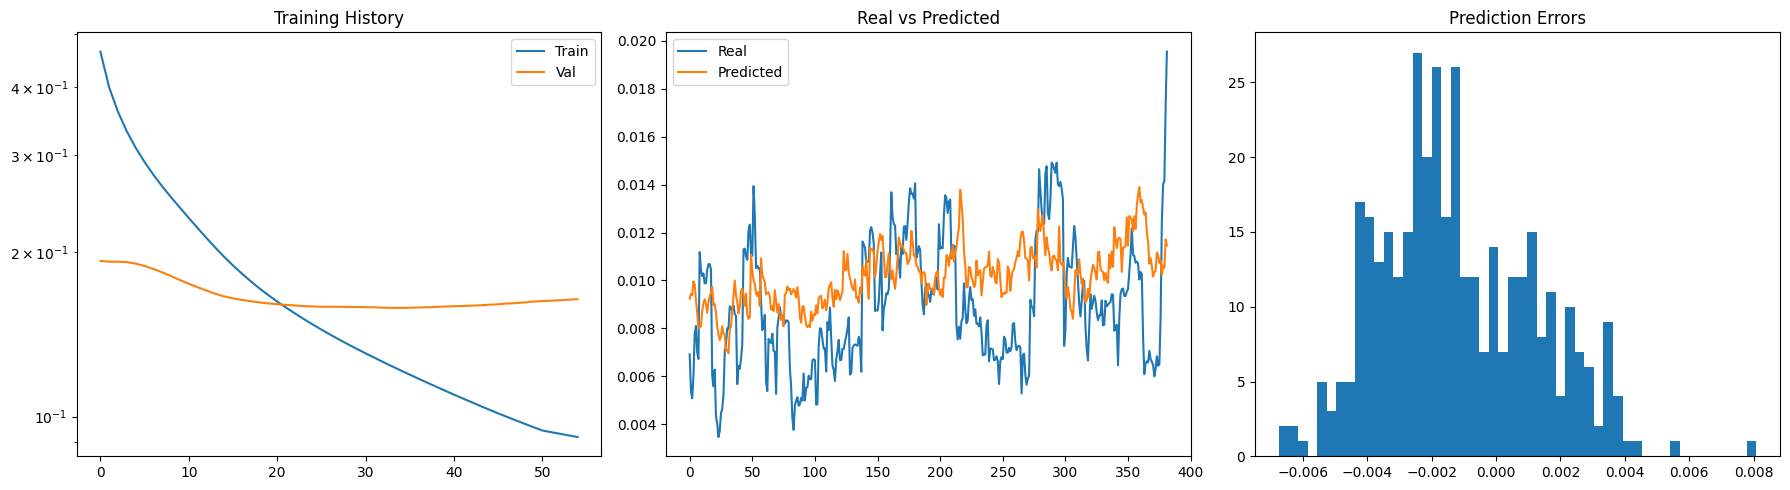

In [73]:
# Célula 12 — Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_yscale('log')
axes[0].set_title("Training History")
axes[0].legend()

axes[1].plot(y_test,                label="Real")
axes[1].plot(y_pred_test.flatten(), label="Predicted")
axes[1].set_title("Real vs Predicted")
axes[1].legend()

errors = y_test - y_pred_test.flatten()
axes[2].hist(errors, bins=50)
axes[2].set_title("Prediction Errors")

plt.tight_layout()
plt.show()

In [74]:
eval_metrics(y_slide[:val_cut], y_pred_slide_train, "LSTM TRAIN (slide)")
eval_metrics(y_test_eval,       y_pred_slide_test,  "LSTM TEST  (slide)")


── LSTM TRAIN (slide) ──
  QLIKE    : 0.024575  (baseline média: 0.085982)
  R²       : 0.7519
  Spearman : 0.7870
  std ratio: 0.766  (ideal=1.0)

── LSTM TEST  (slide) ──
  QLIKE    : 0.041871  (baseline média: 0.041665)
  R²       : 0.0752
  Spearman : 0.4291
  std ratio: 0.559  (ideal=1.0)


In [75]:
# Célula 13 — Diagnóstico de correlações
corr = pd.DataFrame(X.values, columns=X.columns)
corr["target"] = y.values[:len(corr)]
correlations = corr.corr()["target"].drop("target").sort_values(key=abs, ascending=False)
correlations

hist_vol_5                           0.768824
hist_vol_10                          0.675678
hist_vol_20                          0.621365
hist_vol_60                          0.539015
vix                                  0.443846
oil_market_balance_mbd               0.310832
gvz_zscore_60d                       0.291202
eur_usd                              0.266548
gvz_pct_change                       0.238497
usd_rub                             -0.232861
dxy                                 -0.208508
us_shale_production_mbd             -0.191567
platinum_high                        0.187084
platinum_open                        0.186330
platinum_close                       0.186042
platinum_low                         0.185337
petrodolar_brent                     0.166259
sp500                               -0.164370
global_fx_reserves_gold_share_pct   -0.147196
brics_gold_reserves_tonnes          -0.146817
silver_high                          0.141904
opec_compliance_pct               

In [76]:
print("Período completo:", gold["timestamp"].min(), "→", gold["timestamp"].max())
print("Linhas total:", len(gold))
print("\nÚltimas datas do treino (aprox):")
print("Treino vai até ~", gold["timestamp"].iloc[int(len(gold) * 0.9)])
print("Teste começa em ~", gold["timestamp"].iloc[int(len(gold) * 0.9)])

Período completo: 2009-04-15 00:00:00 → 2025-04-03 00:00:00
Linhas total: 3873

Últimas datas do treino (aprox):
Treino vai até ~ 2023-09-18 00:00:00
Teste começa em ~ 2023-09-18 00:00:00


In [77]:
y_train_full.std(), y_test.std()

(np.float64(0.0042499883543624505), np.float64(0.0025832569532560643))

In [78]:
df = pd.DataFrame({
    "Return": y_train_full.flatten()
})
df["Return"].autocorr(lag=1)

np.float64(0.9429836017739243)

In [79]:
df["Return"].autocorr(lag=5)

np.float64(0.7117651985516292)

In [80]:
df["Return"].autocorr(lag=10)

np.float64(0.4230334434795196)

In [81]:
df["Return"].autocorr(lag=20)

np.float64(0.32186832869934134)

In [82]:
y.describe()

count    3873.000000
mean        0.009384
std         0.004643
min         0.002123
25%         0.006628
50%         0.008467
75%         0.010909
max         0.046394
Name: target_vol_5d, dtype: float64

In [83]:
print(y.std())

0.004643472454458806


In [84]:
print("Pred treino std:", y_pred_train.std())
print("Pred teste std:", y_pred_test.std())

print("Real treino std:", y_train_full.std())
print("Real teste std:", y_test.std())

Pred treino std: 0.0024331936
Pred teste std: 0.001220365
Real treino std: 0.0042499883543624505
Real teste std: 0.0025832569532560643


In [85]:
correlations

hist_vol_5                           0.768824
hist_vol_10                          0.675678
hist_vol_20                          0.621365
hist_vol_60                          0.539015
vix                                  0.443846
oil_market_balance_mbd               0.310832
gvz_zscore_60d                       0.291202
eur_usd                              0.266548
gvz_pct_change                       0.238497
usd_rub                             -0.232861
dxy                                 -0.208508
us_shale_production_mbd             -0.191567
platinum_high                        0.187084
platinum_open                        0.186330
platinum_close                       0.186042
platinum_low                         0.185337
petrodolar_brent                     0.166259
sp500                               -0.164370
global_fx_reserves_gold_share_pct   -0.147196
brics_gold_reserves_tonnes          -0.146817
silver_high                          0.141904
opec_compliance_pct               

In [86]:
for col in externos.columns:
    if col != "timestamp":
        first_valid = externos[col].first_valid_index()

        if first_valid is not None:
            print(
                col,
                externos.loc[first_valid, "timestamp"]
            )

dxy 2008-01-02 00:00:00
vix 2008-01-02 00:00:00
oil 2008-01-02 00:00:00
tips 2008-01-02 00:00:00
sp500 2008-01-02 00:00:00
tnx 2008-01-02 00:00:00
gvz 2008-06-03 00:00:00


In [87]:
print("y_train")
print(y_tr.mean(), y_tr.std())

print("\ny_pred")
print(pred.mean(), pred.std())

y_train
0.00930388010018681 0.004327334736656069

y_pred
0.0073680636 0.0017530912


In [88]:
from arch import arch_model
log_ret = gold["log_return"].dropna() * 100  
garch = arch_model(log_ret, vol="Garch", p=1, q=1)
res = garch.fit(disp="off")
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5395.50
Distribution:                  Normal   AIC:                           10799.0
Method:            Maximum Likelihood   BIC:                           10824.0
                                        No. Observations:                 3873
Date:                qui, jun 11 2026   Df Residuals:                     3872
Time:                        19:44:42   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0231  1.514e-02      1.525      0.127 

In [89]:
log_ret = gold["log_return"].dropna() * 100

n_test = int(len(log_ret) * TEST_RATIO)
train_ret = log_ret.iloc[:-n_test]
test_ret  = log_ret.iloc[-n_test:]

preds = []
for i in range(len(test_ret)):
    window = log_ret.iloc[:len(train_ret) + i]
    m = arch_model(window, vol="Garch", p=1, q=1)
    r = m.fit(disp="off", show_warning=False)
    f = r.forecast(horizon=1)
    preds.append(np.sqrt(f.variance.values[-1, 0]) / 100)

realized = test_ret.values / 100
realized_vol = pd.Series(realized).rolling(5).std().shift(-5).dropna().values
preds_aligned = np.array(preds[:len(realized_vol)])

print("GARCH R² no teste:", r2_score(realized_vol, preds_aligned))

GARCH R² no teste: 0.023197626372807534


In [90]:
print("Autocorr y lag1 :", pd.Series(y).autocorr(1))
print("Autocorr y lag5 :", pd.Series(y).autocorr(5))
print("Autocorr y lag10:", pd.Series(y).autocorr(10))
print("Autocorr y lag20:", pd.Series(y).autocorr(20))

Autocorr y lag1 : 0.9353509903681427
Autocorr y lag5 : 0.6754590911900957
Autocorr y lag10: 0.3472731282880403
Autocorr y lag20: 0.3456808462267881


In [97]:
# Célula 131 — Ensemble GARCH + LSTM (slide) com calibração
from scipy.optimize import minimize_scalar
from sklearn.linear_model import LinearRegression

# Val set do slide para otimizar alpha
y_val_true_slide = y_scaler_slide.inverse_transform(
    val_y_slide.reshape(-1, 1)
).ravel()
y_pred_val_slide = y_scaler_slide.inverse_transform(
    final_model.predict(val_X_slide, verbose=0)
).flatten()

# GARCH no período do val slide
n_val_slide = len(val_y_slide)
garch_val_slide = preds_aligned[-(len(y_test) + n_val_slide):-len(y_test)] \
    if len(preds_aligned) >= len(y_test) + n_val_slide \
    else np.full(n_val_slide, np.nan)

# Peso ótimo no val set
def neg_spearman(alpha):
    combo = alpha * garch_val_slide + (1 - alpha) * y_pred_val_slide
    return -spearmanr(y_val_true_slide, combo).statistic

res   = minimize_scalar(neg_spearman, bounds=(0, 1), method="bounded")
alpha = res.x
print(f"Peso ótimo → GARCH: {alpha:.3f}  LSTM: {1-alpha:.3f}")

# Ensemble no val e no teste
ensemble_val = alpha * garch_val_slide + (1 - alpha) * y_pred_val_slide
min_te = min(len(preds_aligned), len(y_pred_slide_test), len(y_test_eval))
ensemble = alpha * preds_aligned[:min_te] + (1 - alpha) * y_pred_slide_test[:min_te]

# Calibração de escala no val set
# Calibração de escala no val set
# Remove NaN antes de calibrar
valid_mask = ~np.isnan(ensemble_val) & ~np.isnan(y_val_true_slide[:len(ensemble_val)])

# Calibração usando só o GRU no val set (GARCH não cobre esse período)
cal = LinearRegression()
cal.fit(y_pred_val_slide.reshape(-1, 1), y_val_true_slide)
ensemble_cal = cal.predict(ensemble.reshape(-1, 1))

# Métricas
eval_metrics(y_test_eval[:min_te], preds_aligned[:min_te],     "GARCH puro")
eval_metrics(y_test_eval[:min_te], y_pred_slide_test[:min_te], "LSTM puro (slide)")
eval_metrics(y_test_eval[:min_te], ensemble,                   f"Ensemble GARCH({alpha:.2f}) + LSTM({1-alpha:.2f})")
eval_metrics(y_test_eval[:min_te], ensemble_cal,               f"Ensemble calibrado GARCH({alpha:.2f}) + LSTM({1-alpha:.2f})")

Peso ótimo → GARCH: 0.382  LSTM: 0.618

── GARCH puro ──
  QLIKE    : 0.039604  (baseline média: 0.041665)
  R²       : 0.0433
  Spearman : 0.3220
  std ratio: 0.404  (ideal=1.0)

── LSTM puro (slide) ──
  QLIKE    : 0.041871  (baseline média: 0.041665)
  R²       : 0.0752
  Spearman : 0.4291
  std ratio: 0.559  (ideal=1.0)

── Ensemble GARCH(0.38) + LSTM(0.62) ──
  QLIKE    : 0.034621  (baseline média: 0.041665)
  R²       : 0.1762
  Spearman : 0.4676
  std ratio: 0.446  (ideal=1.0)

── Ensemble calibrado GARCH(0.38) + LSTM(0.62) ──
  QLIKE    : 0.035200  (baseline média: 0.041665)
  R²       : 0.1494
  Spearman : 0.4676
  std ratio: 0.553  (ideal=1.0)


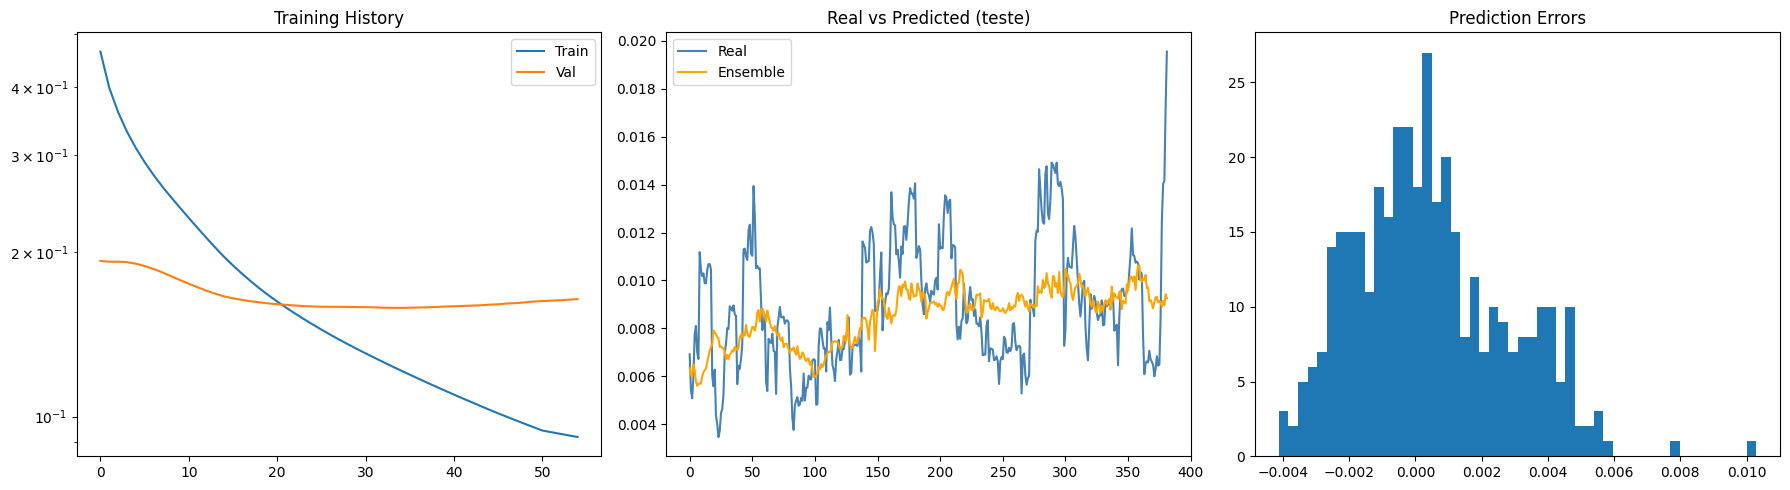

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

min_te = min(len(preds_aligned), len(y_pred_slide_test), len(y_test_eval))

# Training History
axes[0].plot(history.history["loss"],     label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_yscale("log")
axes[0].set_title("Training History")
axes[0].legend()

# Real vs Ensemble
axes[1].plot(y_test_eval[:min_te],  label="Real",     color="steelblue")
axes[1].plot(ensemble,              label="Ensemble", color="orange")
axes[1].set_title("Real vs Predicted (teste)")
axes[1].legend()

# Erros do ensemble
errors = y_test_eval[:min_te] - ensemble
axes[2].hist(errors, bins=50)
axes[2].set_title("Prediction Errors")

plt.tight_layout()
plt.show()

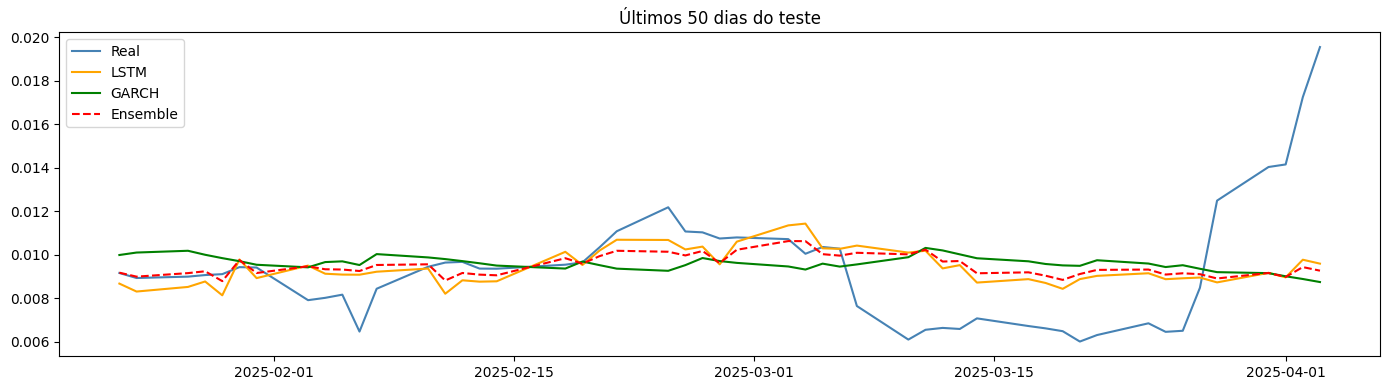

In [99]:
fig, ax = plt.subplots(figsize=(14, 4))

min_te = min(len(preds_aligned), len(y_pred_slide_test), len(y_test_eval))
test_timestamps = seq_ts.iloc[-len(y_test_eval):]

ax.plot(test_timestamps.values[-50:], y_test_eval[-50:],          label="Real",     color="steelblue")
ax.plot(test_timestamps.values[-50:], y_pred_slide_test[-50:],    label="LSTM",     color="orange")
ax.plot(test_timestamps.values[-50:], preds_aligned[-50:],        label="GARCH",    color="green")
ax.plot(test_timestamps.values[-50:], ensemble[-50:],             label="Ensemble", color="red", linestyle="--")

ax.set_title("Últimos 50 dias do teste")
ax.legend()
plt.tight_layout()
plt.show()

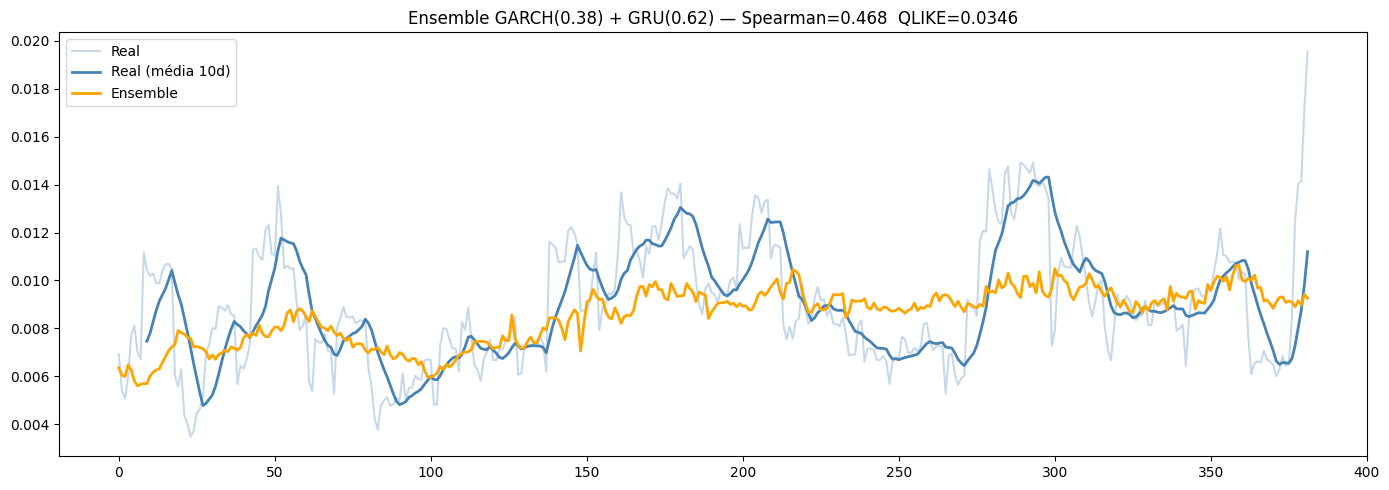

In [100]:
fig, ax = plt.subplots(figsize=(14, 5))

min_te = min(len(preds_aligned), len(y_pred_slide_test), len(y_test_eval))

real_smooth = pd.Series(y_test_eval[:min_te]).rolling(10).mean()

ax.plot(y_test_eval[:min_te], label="Real",           color="steelblue", alpha=0.3)
ax.plot(real_smooth,          label="Real (média 10d)", color="steelblue", linewidth=2)
ax.plot(ensemble,             label="Ensemble",        color="orange",    linewidth=2)

ax.set_title(f"Ensemble GARCH(0.38) + GRU(0.62) — Spearman={spearmanr(y_test_eval[:min_te], ensemble).statistic:.3f}  QLIKE={qlike(y_test_eval[:min_te], ensemble):.4f}")
ax.legend()
plt.tight_layout()
plt.show()